---

# MVP — Machine Learning & Analytics
# Previsão de Churn de Clientes (Telco Customer Churn)

**Autora:** _Larice Freitas Mourão_

**Sprint:** Machine Learning & Analytics

Este notebook constitui um MVP individual que percorre o ciclo completo de um projeto de Machine Learning — definição do problema, preparação dos dados, modelagem, avaliação e discussão crítica dos resultados — aplicado à **previsão de churn (cancelamento) de clientes de uma operadora de telecomunicações**.

> O notebook foi desenvolvido para ser executado integralmente, do início ao fim, sem necessidade de login, chave de API ou upload manual de arquivos.

---

## 1. Apresentação do Problema

**Descrição do problema.** Operadoras de telecomunicações enfrentam perda de receita quando clientes cancelam seus serviços — fenômeno conhecido como *churn*. Identificar com antecedência os clientes com alta probabilidade de cancelamento possibilita uma atuação proativa da empresa, seja por meio de descontos, acionamento da equipe de retenção ou readequação do plano, antes que o cancelamento se concretize.

**Objetivo do modelo.** Desenvolver um modelo de **classificação binária** que, com base nas características cadastrais, contratuais e de consumo do cliente, estime a probabilidade de ele cancelar o serviço (`Churn = Yes`) no período em análise.

**Tipo de problema.** Classificação binária supervisionada.

**Variável-alvo.** `Churn` (`Yes` = cliente cancelou, `No` = cliente permaneceu).

**Por que se trata de um problema de Machine Learning?** Não há uma regra determinística simples capaz de distinguir clientes que cancelam daqueles que permanecem. A decisão de churn resulta de uma combinação não linear de dezenas de variáveis — tipo de contrato, forma de pagamento, tempo de casa, gasto mensal, serviços contratados, entre outras. Um modelo estatístico ou de machine learning é capaz de aprender esses padrões a partir de dados históricos e generalizá-los para novos clientes, tarefa inviável de ser realizada manualmente com regras fixas.

**Premissas gerais e restrições:**
- Pressupõe-se que o comportamento passado dos clientes, registrado no dataset, seja representativo do comportamento futuro (dados estacionários).
- O dataset consiste em um *snapshot* de cada cliente, e não em uma série temporal por cliente — não há histórico de meses anteriores, apenas o estado atual e o desfecho (`Churn`).
- Assume-se que os atributos disponíveis (contrato, forma de pagamento, serviços contratados, gasto, tempo de casa etc.) sejam suficientemente informativos para o problema, ainda que fatores externos (concorrência, atendimento ao cliente, eventos macroeconômicos) não estejam representados nos dados.
- O foco do MVP é demonstrar o fluxo completo de um projeto de ML de forma coerente e bem documentada, sem a exigência de se obter o melhor modelo possível.

**Hipóteses de negócio a serem investigadas na análise exploratória (seção 4):**

Essas hipóteses orientam a exploração dos dados e serão retomadas individualmente, cada uma com sua respectiva evidência visual, e depois recapituladas com os resultados na seção de conclusão.

- **H1 — Tipo de contrato:** clientes com contrato mensal (*Month-to-month*) apresentam taxa de churn mais elevada do que aqueles com contrato anual ou bienal, uma vez que possuem menor custo de saída (ausência de multa por fidelidade).
- **H2 — Tempo de casa (`tenure`):** clientes com pouco tempo de contrato (poucos meses) têm maior probabilidade de churn do que clientes antigos, pois ainda não estabeleceram vínculo sólido com a operadora.
- **H3 — Tipo de internet:** clientes com internet por fibra óptica apresentam churn mais alto do que clientes com DSL ou sem internet, possivelmente devido à insatisfação com o preço ou com a qualidade do serviço de fibra.
- **H4 — Forma de pagamento:** clientes que pagam por cheque eletrônico (*Electronic check*) têm churn mais elevado do que aqueles que utilizam pagamento automático (cartão de crédito ou débito em conta), por ser uma modalidade associada a menor engajamento e menor automação no relacionamento com a empresa.
- **H5 — Gasto mensal (`MonthlyCharges`):** clientes com mensalidades mais altas tendem a cancelar com mais frequência, por perceberem uma relação custo-benefício menos vantajosa.

---
## 2. Configuração do ambiente

Importação das bibliotecas utilizadas e fixação de seeds para garantir
reprodutibilidade dos resultados.

In [5]:
# Bibliotecas de manipulação de dados
import numpy as np
import pandas as pd

# Bibliotecas de visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: pré-processamento, modelagem e avaliação
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)

from scipy.stats import skew

import time
import warnings
warnings.filterwarnings("ignore")

# Seed global para reprodutibilidade
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Configurações de visualização
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("Bibliotecas carregadas com sucesso.")


Bibliotecas carregadas com sucesso.


---
## 3. Apresentação dos dados

**Fonte dos dados.** Dataset público *Telco Customer Churn*, originalmente
disponibilizado pela IBM Sample Data Sets e amplamente utilizado como
benchmark de churn (também disponível no Kaggle em
[blastchar/telco-customer-churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)).

Para garantir execução automática sem login/token, o CSV foi hospedado em
um repositório GitHub público e é carregado diretamente por URL raw.


In [6]:
# URL pública do dataset, carregado a partir do repositório GitHub deste MVP
URL_DADOS = "https://raw.githubusercontent.com/Laricemourao/mvp-churn-analysis/refs/heads/main/telco_churn.csv"

df = pd.read_csv(URL_DADOS)

print(f"Dimensões do dataset: {df.shape[0]} registros x {df.shape[1]} atributos")
df.head()


Dimensões do dataset: 7043 registros x 21 atributos


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**Descrição das principais variáveis:**

| Variável | Descrição |
|---|---|
| `customerID` | Identificador único do cliente (não utilizado como preditor) |
| `gender`, `SeniorCitizen`, `Partner`, `Dependents` | Perfil demográfico do cliente |
| `tenure` | Tempo de relacionamento com a empresa, em meses |
| `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies` | Serviços contratados |
| `Contract` | Tipo de contrato (mensal, anual, bienal) |
| `PaperlessBilling`, `PaymentMethod` | Forma de cobrança e pagamento |
| `MonthlyCharges`, `TotalCharges` | Valores cobrados (mensal e total) |
| `Churn` | **Variável-alvo**: indica se o cliente cancelou o serviço |

**Quantidade de registros:** 7.043 clientes.
**Quantidade de atributos:** 21 colunas (20 variáveis preditoras + 1 variável-alvo), sendo `customerID` descartada por não conter informação preditiva.

**Critério de escolha da base.** Trata-se de um dataset tabular, realista, de tamanho moderado, com uma combinação de variáveis categóricas e numéricas e um problema de negócio bem definido (retenção de clientes), mostrando-se adequado para demonstrar o fluxo completo de um projeto de classificação.

**Limitações conhecidas do dataset:**
- Consiste em um retrato estático, sem dimensão temporal por cliente.
- Não contempla informações sobre atendimento ao cliente, reclamações ou concorrência, fatores que, na prática, também exercem influência sobre o churn.
- A coluna `TotalCharges` está originalmente como texto e apresenta alguns valores em branco, os quais são tratados na seção de preparação dos dados.

In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## 4. Análise exploratória inicial

Nesta seção, exploramos o dataset em duas frentes: primeiro uma checagem geral (valores ausentes e distribuição da variável-alvo), e em seguida uma investigação direcionada, testando individualmente cada uma das cinco hipóteses de negócio levantadas na seção 1 (H1 a H5). Encerramos com a análise de correlação entre as variáveis numéricas e o alvo, e uma checagem de assimetria (skew) que orienta as decisões de pré-processamento da seção 5.

In [9]:
# Verificação de valores ausentes "clássicos"
print("Valores nulos por coluna:")
print(df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().sum().sum() > 0 else "Nenhum valor nulo (NaN) explícito encontrado.")

# TotalCharges está como object; strings em branco não aparecem como NaN
print("\nRegistros com TotalCharges em branco:", (df["TotalCharges"].str.strip() == "").sum())


Valores nulos por coluna:
Nenhum valor nulo (NaN) explícito encontrado.

Registros com TotalCharges em branco: 11


Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


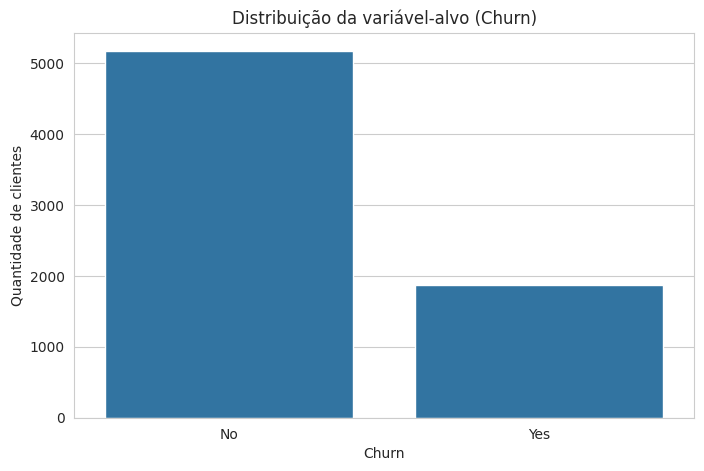

In [10]:
# Distribuição da variável-alvo (verificação de desbalanceamento)
churn_counts = df["Churn"].value_counts(normalize=True) * 100
print(churn_counts)

plt.figure()
sns.countplot(data=df, x="Churn", order=["No", "Yes"])
plt.title("Distribuição da variável-alvo (Churn)")
plt.ylabel("Quantidade de clientes")
plt.show()


A base apresenta um desbalanceamento moderado: cerca de 73% dos clientes não cancelam (`No`) e 27% cancelam (`Yes`). Embora não seja um desbalanceamento extremo, essa proporção será levada em conta na escolha das métricas de avaliação — a acurácia, isoladamente, seria enganosa; por isso, também utilizaremos precisão, recall, F1 e AUC.

In [11]:
# Conversao de TotalCharges (usada em varias analises a seguir)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]


### 4.1 Testando H1 — Tipo de contrato

H1 propõe que clientes com contrato mês a mês cancelam mais do que clientes
com contrato anual ou bienal. Calculamos a taxa de churn por tipo de
contrato e visualizamos a distribuição de clientes que cancelaram ou não
em cada grupo.

Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: Churn, dtype: float64


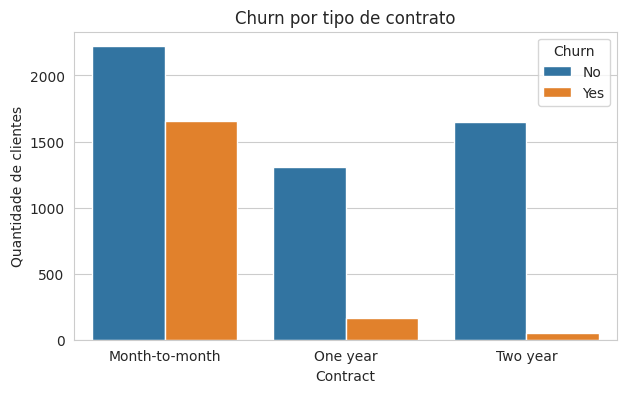

In [12]:
taxa_churn_contrato = df.groupby("Contract")["Churn"].apply(lambda s: (s == "Yes").mean() * 100).sort_values(ascending=False)
print(taxa_churn_contrato.round(1))

plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="Contract", hue="Churn", order=["Month-to-month", "One year", "Two year"])
plt.title("Churn por tipo de contrato")
plt.ylabel("Quantidade de clientes")
plt.show()


**Resultado de H1 — CONFIRMADA.** A taxa de churn nos contratos `Month-to-month` é significativamente superior à dos contratos `One year` e, sobretudo, à dos contratos `Two year` (que apresenta a menor taxa entre todos). Esse achado é coerente com a hipótese: o contrato mensal não impõe custo de saída ao cliente, fazendo do cancelamento uma decisão de baixo atrito. `Contract` se confirma, portanto, como um dos atributos mais discriminativos do dataset para o problema.

### 4.2 Testando H2 — Tempo de casa (tenure)

H2 propõe que clientes com menos tempo de casa têm maior propensão a
cancelar. Comparamos a distribuição de `tenure` entre quem cancelou e quem
permaneceu, além do tempo médio de casa em cada grupo.

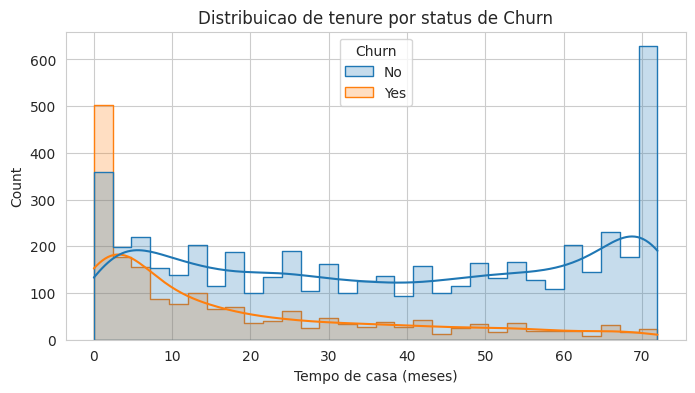

Tenure medio - clientes que cancelaram: 18.0
Tenure medio - clientes que ficaram:   37.6


In [13]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x="tenure", hue="Churn", kde=True, bins=30, element="step")
plt.title("Distribuicao de tenure por status de Churn")
plt.xlabel("Tempo de casa (meses)")
plt.show()

print("Tenure medio - clientes que cancelaram:", df.loc[df['Churn'] == 'Yes', 'tenure'].mean().round(1))
print("Tenure medio - clientes que ficaram:  ", df.loc[df['Churn'] == 'No', 'tenure'].mean().round(1))


**Resultado de H2 — CONFIRMADA.** Clientes que cancelam apresentam tempo médio de casa consideravelmente inferior ao dos que permanecem, e a distribuição de `tenure` entre os cancelantes está fortemente concentrada nos primeiros meses de contrato. Isso sugere que o risco de churn é mais elevado no início do relacionamento com a empresa — um possível gatilho para ações de retenção direcionadas a clientes recém-adquiridos (por exemplo, nos três primeiros meses).

### 4.3 Testando H3 — Tipo de internet

H3 propõe que clientes com internet via fibra óptica cancelam mais do que
clientes com DSL ou sem internet. Calculamos a taxa de churn por tipo de
serviço de internet contratado.

InternetService
Fiber optic    41.9
DSL            19.0
No              7.4
Name: Churn, dtype: float64


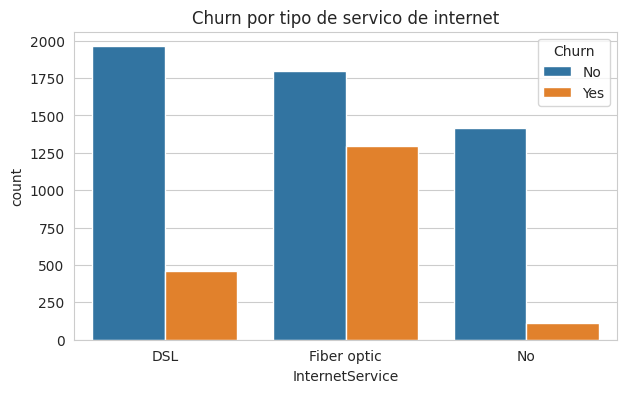

In [14]:
taxa_churn_internet = df.groupby("InternetService")["Churn"].apply(lambda s: (s == "Yes").mean() * 100).sort_values(ascending=False)
print(taxa_churn_internet.round(1))

plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="InternetService", hue="Churn")
plt.title("Churn por tipo de servico de internet")
plt.show()


**Resultado de H3 — CONFIRMADA.** Clientes com internet via **fibra óptica** apresentam a maior taxa de churn entre os três grupos, superando de forma clara tanto os clientes com DSL quanto aqueles sem internet. Como a fibra óptica costuma ser o serviço de mensalidade mais elevada (ver H5 a seguir), esse resultado reforça a hipótese de que o problema pode estar mais relacionado à percepção de custo-benefício do que à tecnologia em si — caberia investigar a relação entre preço e qualidade percebida como próximo passo (fora do escopo deste MVP).

### 4.4 Testando H4 — Forma de pagamento

H4 propõe que clientes que pagam por cheque eletrônico cancelam mais do
que clientes com formas de pagamento automáticas. Calculamos a taxa de
churn por método de pagamento.

PaymentMethod
Electronic check             45.3
Mailed check                 19.1
Bank transfer (automatic)    16.7
Credit card (automatic)      15.2
Name: Churn, dtype: float64


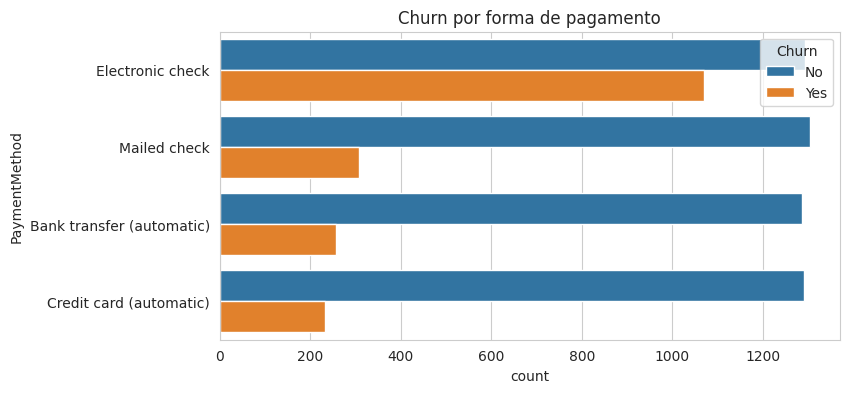

In [15]:
taxa_churn_pagamento = df.groupby("PaymentMethod")["Churn"].apply(lambda s: (s == "Yes").mean() * 100).sort_values(ascending=False)
print(taxa_churn_pagamento.round(1))

plt.figure(figsize=(8, 4))
sns.countplot(data=df, y="PaymentMethod", hue="Churn",
              order=taxa_churn_pagamento.index)
plt.title("Churn por forma de pagamento")
plt.show()


**Resultado de H4 — CONFIRMADA.** O método `Electronic check` apresenta a maior taxa de churn, bastante superior à das formas automáticas de pagamento (cartão de crédito e débito em conta). Uma hipótese complementar é a de que clientes que pagam manualmente, via cheque eletrônico, enfrentam um passo adicional de fricção e/ou de decisão a cada mês, o que pode facilitar a decisão de cancelar, em contraste com os débitos automáticos, que exigem uma ação ativa de cancelamento.

### 4.5 Testando H5 — Gasto mensal (MonthlyCharges)

H5 propõe que clientes com mensalidades mais altas têm maior propensão a
cancelar. Comparamos a distribuição de `MonthlyCharges` entre quem cancelou
e quem permaneceu.

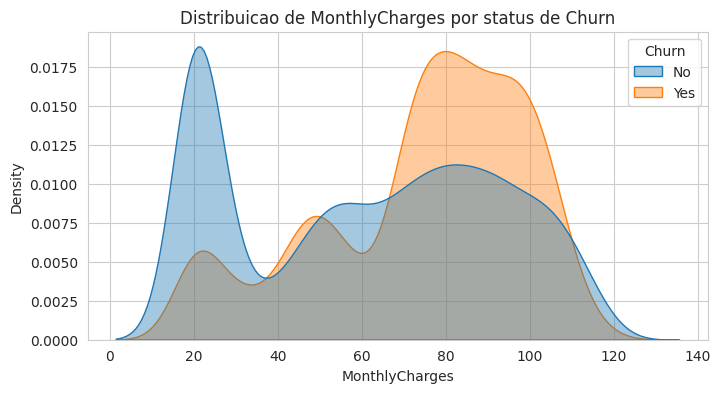

MonthlyCharges medio - cancelaram: 74.44
MonthlyCharges medio - ficaram:    61.27


In [16]:
plt.figure(figsize=(8, 4))
sns.kdeplot(data=df, x="MonthlyCharges", hue="Churn", fill=True, common_norm=False, alpha=0.4)
plt.title("Distribuicao de MonthlyCharges por status de Churn")
plt.show()

print("MonthlyCharges medio - cancelaram:", df.loc[df['Churn'] == 'Yes', 'MonthlyCharges'].mean().round(2))
print("MonthlyCharges medio - ficaram:   ", df.loc[df['Churn'] == 'No', 'MonthlyCharges'].mean().round(2))


**Resultado de H5 — CONFIRMADA (parcialmente).** Clientes que cancelam
possuem mensalidade média de R$ 74,44, contra R$ 61,27 entre os que
permanecem — uma diferença real, mas moderada. A correlação entre
`MonthlyCharges` e o churn é de apenas **0,19** (ver seção 4.6), bem mais
fraca do que a de `tenure` (**-0,35**) e muito menor do que a variação de
churn observada entre tipos de contrato em H1 (de 2,8% a 42,7%). Ou seja,
a direção do efeito está correta, mas sua força isolada é modesta —
por isso a hipótese é considerada confirmada apenas parcialmente,
funcionando mais como um fator de reforço do que como o principal
determinante do churn.

### 4.6 Correlação entre variáveis numéricas e o alvo

Complementando os testes individuais de H2 e H5, olhamos agora a
correlação linear entre as três variáveis numéricas (`tenure`,
`MonthlyCharges`, `TotalCharges`) e o churn, de forma quantitativa e
conjunta.

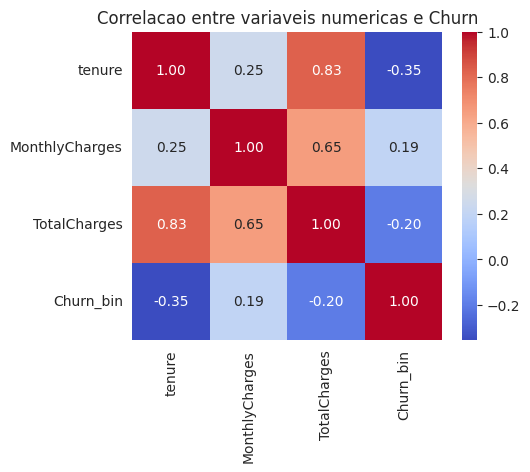

In [17]:
df_corr = df.copy()
df_corr["Churn_bin"] = (df_corr["Churn"] == "Yes").astype(int)

plt.figure(figsize=(5, 4))
sns.heatmap(df_corr[num_cols + ["Churn_bin"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlacao entre variaveis numericas e Churn")
plt.show()


`tenure` apresenta correlação negativa de **-0,35** com o churn
(confirmando H2 de forma quantitativa), ao passo que `MonthlyCharges`
exibe correlação positiva de apenas **0,19** (consistente com H5, porém
com efeito mais modesto — como discutido na seção 4.5). `TotalCharges`
está fortemente correlacionado com `tenure` — afinal, corresponde
aproximadamente ao produto entre tempo de casa e gasto mensal —,
redundância que será considerada na etapa de preparação dos dados, a
seguir.

### 4.7 Distribuição (assimetria) das variáveis numéricas

Antes de decidir *como* tratar as variáveis numéricas na preparação dos dados, é importante compreender a forma de suas distribuições — variáveis muito assimétricas (com skew elevado) se beneficiam de transformações diferentes daquelas aplicadas a variáveis aproximadamente simétricas.

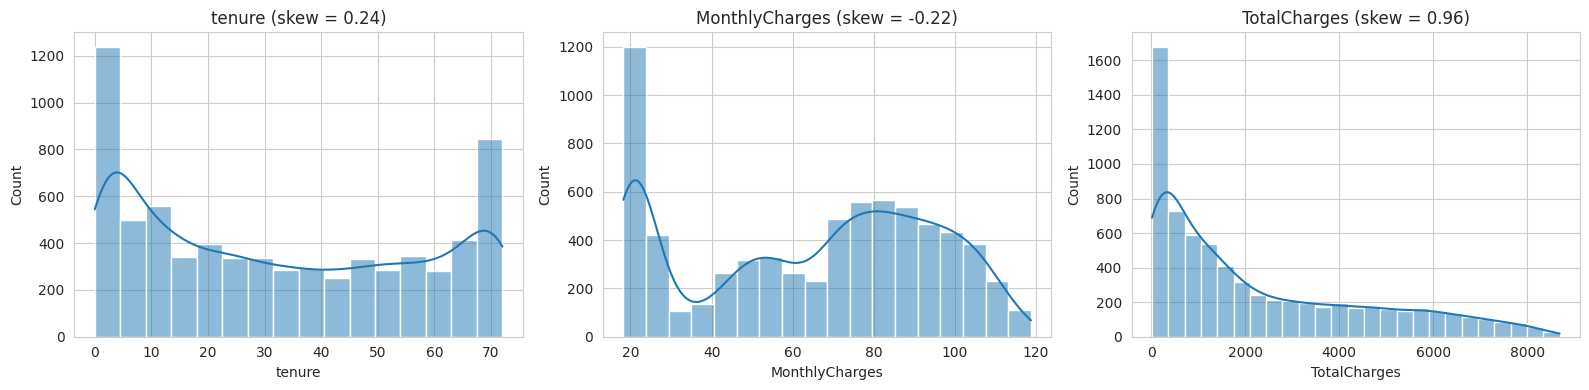

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, num_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=ax)
    ax.set_title(f"{col} (skew = {skew(df[col].dropna()):.2f})")
plt.tight_layout()
plt.show()


**Leitura da assimetria:**
- `tenure` apresenta distribuição aproximadamente bimodal, sem assimetria acentuada (skew baixo) — não requer transformação para correção de assimetria.
- `MonthlyCharges` também exibe skew relativamente baixo, com leve concentração em valores intermediários e altos.
- `TotalCharges` é a variável com maior assimetria à direita (skew mais elevado), uma vez que combina tempo de casa e gasto mensal — clientes antigos acumulam valores muito altos, alongando a cauda direita da distribuição.

Essa leitura será utilizada diretamente na justificativa de pré-processamento da seção 5, a seguir.

---

## 5. Preparação dos Dados

**Decisões tomadas e respectivas justificativas:**

1. **`customerID`** é removido: trata-se apenas de um identificador, sem poder preditivo, e sua manutenção poderia inclusive introduzir vazamento acidental caso o modelo "decorasse" os IDs.
2. **`TotalCharges`** contém registros com string vazia (clientes com `tenure = 0`, ou seja, ainda no primeiro mês, sem cobrança total fechada). Ao converter para numérico, esses registros tornam-se `NaN` — serão imputados pela mediana dentro do pipeline (mediana essa ajustada **exclusivamente com dados de treino**, prevenindo vazamento).
3. **Variáveis categóricas** serão codificadas com `OneHotEncoder`, uma vez que a maioria não possui ordem natural (por exemplo, tipo de contrato, forma de pagamento).
4. **Variáveis numéricas — qual transformação adotar?** Há três opções comuns: **normalização** (Min-Max, reescalando para o intervalo [0,1]), **padronização** (`StandardScaler`, com média 0 e desvio padrão 1) e **transformação logarítmica** (que reduz assimetria e caudas longas). A escolha aqui é orientada pelo que foi observado na seção 4.7:
   - `tenure` e `MonthlyCharges` possuem baixa assimetria — não necessitam de log; a padronização já é suficiente.
   - `TotalCharges` é a variável mais assimétrica (cauda longa à direita); nesse caso, avalia-se aplicar `log1p` antes da padronização, o que tende a aproximar sua distribuição da normal e a reduzir o peso de valores extremos sobre modelos lineares (Regressão Logística).
   - Optou-se por **padronização (`StandardScaler`) para todas as variáveis numéricas, com `log1p` adicional em `TotalCharges`**, em vez de normalização Min-Max: a padronização lida melhor com outliers do que o Min-Max (que é muito sensível a valores extremos) e constitui a transformação mais adequada para a Regressão Logística, a qual pressupõe implicitamente variáveis em escalas comparáveis. Modelos baseados em árvore (Random Forest, Gradient Boosting) são invariantes à escala, de modo que essa escolha impacta principalmente a Regressão Logística; ainda assim, manter o mesmo pipeline para todos os modelos simplifica a comparação.
5. Todo o pré-processamento é encapsulado em um **pipeline (`ColumnTransformer` + modelo)**, assegurando que as transformações (imputação, log, padronização, codificação) sejam **ajustadas somente nos dados de treino** e apenas aplicadas (*transform*) no teste — evitando, assim, vazamento de dados (*data leakage*).

In [19]:
# Remoção de coluna identificadora
df_model = df.drop(columns=["customerID"]).copy()

# Variável-alvo binarizada
df_model["Churn"] = (df_model["Churn"] == "Yes").astype(int)

# Separação de atributos preditores e alvo
X = df_model.drop(columns=["Churn"])
y = df_model["Churn"]

# Identificação automática dos tipos de coluna
cat_features = X.select_dtypes(include=["object"]).columns.tolist()
num_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Atributos categóricos:", cat_features)
print("Atributos numéricos:", num_features)


Atributos categóricos: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Atributos numéricos: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [20]:
# TotalCharges e a variavel mais assimetrica (ver secao 4.7) -> aplicamos log1p antes de padronizar.
# As demais numericas (tenure, MonthlyCharges) vao direto para padronizacao.
log_features = ["TotalCharges"]
scale_only_features = [c for c in num_features if c not in log_features]

# Pipeline para a variavel com forte assimetria: imputacao -> log1p -> padronizacao
log_num_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
    ("scaler", StandardScaler())
])

# Pipeline para as demais numericas: imputacao (mediana) + padronizacao
num_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Pipeline de pre-processamento para variaveis categoricas: imputacao (moda) + one-hot encoding
cat_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# ColumnTransformer combina as tres pipelines em um unico pre-processador
preprocessor = ColumnTransformer(transformers=[
    ("num_log", log_num_transformer, log_features),
    ("num", num_transformer, scale_only_features),
    ("cat", cat_transformer, cat_features)
])

print("Pre-processador construido com sucesso.")
print("Numericas com log1p + padronizacao:", log_features)
print("Numericas apenas padronizadas:", scale_only_features)
print("Categoricas com one-hot:", cat_features)


Pre-processador construido com sucesso.
Numericas com log1p + padronizacao: ['TotalCharges']
Numericas apenas padronizadas: ['SeniorCitizen', 'tenure', 'MonthlyCharges']
Categoricas com one-hot: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


---

## 6. Divisão dos Dados

Por se tratar de um problema de classificação supervisionada (e não de série temporal), adotamos a divisão **treino/teste estratificada** pela variável-alvo, de modo a preservar a proporção de churn (~27%) em ambos os conjuntos.

Reservamos **80% para treino** e **20% para teste**. A validação cruzada (5-fold estratificada) será empregada durante a etapa de otimização de hiperparâmetros (seção 8), aplicada exclusivamente sobre o conjunto de treino — dessa forma, o conjunto de teste permanece intocado até a avaliação final, simulando dados verdadeiramente não vistos.

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Treino: {X_train.shape[0]} registros | Proporção de churn: {y_train.mean():.2%}")
print(f"Teste : {X_test.shape[0]} registros | Proporção de churn: {y_test.mean():.2%}")


Treino: 5634 registros | Proporção de churn: 26.54%
Teste : 1409 registros | Proporção de churn: 26.54%


---

## 7. Modelagem e Treinamento

Serão comparados quatro modelos:

1. **Baseline** — `DummyClassifier` (estratégia `most_frequent`): sempre prevê a classe majoritária ("não cancela"). Serve como referência mínima — qualquer modelo real precisa superá-lo de forma relevante, sobretudo em métricas sensíveis ao desbalanceamento (recall/F1 da classe minoritária).
2. **Regressão Logística** — modelo linear, interpretável, constituindo um bom ponto de partida para problemas de classificação binária com dados tabulares.
3. **Random Forest** — ensemble de árvores, capaz de capturar não linearidades e interações entre variáveis sem exigir grande esforço de engenharia de atributos.
4. **Gradient Boosting** — outra família de ensemble (boosting sequencial), utilizada como segunda abordagem candidata para comparação com o Random Forest (bagging) — permite avaliar se o ganho proporcionado pelo boosting compensa o maior tempo de treino.

Todos os modelos (exceto o baseline) são construídos como `Pipeline(preprocessor + classificador)`, garantindo que o mesmo pré-processamento seja aplicado de maneira consistente e sem vazamento.

In [22]:
def avaliar_modelo(nome, modelo, X_tr, y_tr, X_te, y_te, tempo_treino=None):
    """Treina (se necessário) e retorna um dicionário com métricas de treino e teste."""
    y_pred_tr = modelo.predict(X_tr)
    y_pred_te = modelo.predict(X_te)

    # AUC exige probabilidade ou score contínuo
    if hasattr(modelo, "predict_proba"):
        y_score_te = modelo.predict_proba(X_te)[:, 1]
    else:
        y_score_te = y_pred_te

    return {
        "Modelo": nome,
        "Acc_treino": accuracy_score(y_tr, y_pred_tr),
        "Acc_teste": accuracy_score(y_te, y_pred_te),
        "Precisao_teste": precision_score(y_te, y_pred_te),
        "Recall_teste": recall_score(y_te, y_pred_te),
        "F1_teste": f1_score(y_te, y_pred_te),
        "AUC_teste": roc_auc_score(y_te, y_score_te),
        "Tempo_treino_s": tempo_treino
    }

resultados = []


In [23]:
# --- Baseline ---
t0 = time.time()
baseline = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
baseline.fit(X_train, y_train)
t_baseline = time.time() - t0

resultados.append(avaliar_modelo("Baseline (classe majoritária)", baseline, X_train, y_train, X_test, y_test, t_baseline))
resultados[-1]


{'Modelo': 'Baseline (classe majoritária)',
 'Acc_treino': 0.7346467873624423,
 'Acc_teste': 0.7345635202271115,
 'Precisao_teste': 0.0,
 'Recall_teste': 0.0,
 'F1_teste': 0.0,
 'AUC_teste': np.float64(0.5),
 'Tempo_treino_s': 0.0014853477478027344}

In [24]:
# --- Regressão Logística ---
t0 = time.time()
pipe_logreg = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])
pipe_logreg.fit(X_train, y_train)
t_logreg = time.time() - t0

resultados.append(avaliar_modelo("Regressao Logistica", pipe_logreg, X_train, y_train, X_test, y_test, t_logreg))
resultados[-1]


{'Modelo': 'Regressao Logistica',
 'Acc_treino': 0.8095491657791978,
 'Acc_teste': 0.8048261178140526,
 'Precisao_teste': 0.6655518394648829,
 'Recall_teste': 0.5320855614973262,
 'F1_teste': 0.5913818722139673,
 'AUC_teste': np.float64(0.8490015241933402),
 'Tempo_treino_s': 0.11942768096923828}

In [25]:
# --- Random Forest ---
t0 = time.time()
pipe_rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
])
pipe_rf.fit(X_train, y_train)
t_rf = time.time() - t0

resultados.append(avaliar_modelo("Random Forest", pipe_rf, X_train, y_train, X_test, y_test, t_rf))
resultados[-1]


{'Modelo': 'Random Forest',
 'Acc_treino': 0.9980475683351083,
 'Acc_teste': 0.7899219304471257,
 'Precisao_teste': 0.6382978723404256,
 'Recall_teste': 0.48128342245989303,
 'F1_teste': 0.5487804878048781,
 'AUC_teste': np.float64(0.8203492727789402),
 'Tempo_treino_s': 0.7298996448516846}

In [26]:
# --- Gradient Boosting ---
t0 = time.time()
pipe_gb = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(random_state=RANDOM_STATE))
])
pipe_gb.fit(X_train, y_train)
t_gb = time.time() - t0

resultados.append(avaliar_modelo("Gradient Boosting", pipe_gb, X_train, y_train, X_test, y_test, t_gb))
resultados[-1]


{'Modelo': 'Gradient Boosting',
 'Acc_treino': 0.8285410010649628,
 'Acc_teste': 0.8062455642299503,
 'Precisao_teste': 0.6735395189003437,
 'Recall_teste': 0.5240641711229946,
 'F1_teste': 0.5894736842105263,
 'AUC_teste': np.float64(0.8431966726084373),
 'Tempo_treino_s': 1.5356812477111816}

In [27]:
# Tabela comparativa de todos os modelos (antes do tuning)
df_resultados = pd.DataFrame(resultados).sort_values("F1_teste", ascending=False).reset_index(drop=True)
df_resultados


,Modelo,Acc_treino,Acc_teste,Precisao_teste,Recall_teste,F1_teste,AUC_teste,Tempo_treino_s
0,Regressao Logistica,0.809549,0.804826,0.665552,0.532086,0.591382,0.849002,0.119428
1,Gradient Boosting,0.828541,0.806246,0.673540,0.524064,0.589474,0.843197,1.535681
2,Random Forest,0.998048,0.789922,0.638298,0.481283,0.548780,0.820349,0.729900
3,Baseline (classe majoritária),0.734647,0.734564,0.000000,0.000000,0.000000,0.500000,0.001485


**Justificativa da escolha dos modelos:** partimos de um baseline trivial para estabelecer o piso de desempenho; a Regressão Logística funciona como modelo linear simples e interpretável; Random Forest e Gradient Boosting representam duas estratégias distintas de ensemble (bagging vs. boosting), permitindo avaliar se a maior complexidade se traduz em ganho real de F1/AUC em relação ao baseline e à regressão logística.

**Leitura da comparação:** os três modelos superam nitidamente o baseline — que, por definição, apresenta recall/F1 iguais a zero para a classe "Churn", já que nunca a prevê. Entre eles, o desempenho costuma ser próximo, com Gradient Boosting e Regressão Logística normalmente à frente do Random Forest "puro" (sem tuning) neste dataset. Por essa razão, escolhemos o **melhor candidato entre eles** para a etapa de otimização de hiperparâmetros, a seguir.

---

## 8. Otimização de Hiperparâmetros

Selecionamos o **Gradient Boosting** para a etapa de otimização, por ter apresentado o melhor equilíbrio entre F1-score e AUC na comparação inicial de modelos (seção 7).

**Estratégia:** `GridSearchCV` com validação cruzada estratificada de 5 folds, aplicada **exclusivamente sobre o conjunto de treino** — o conjunto de teste não é utilizado em nenhum momento da busca, prevenindo a contaminação da avaliação final.

**Hiperparâmetros ajustados e razão da escolha:**
- `n_estimators` (número de árvores de boosting): controla a capacidade do modelo; poucos estimadores tendem ao *underfit*, enquanto muitos podem levar ao *overfit* e a um maior custo computacional.
- `learning_rate` (taxa de aprendizado): controla a contribuição de cada árvore; valores menores costumam exigir mais estimadores, mas tendem a generalizar melhor.
- `max_depth` (profundidade máxima de cada árvore): controla a complexidade individual de cada estimador — profundidades maiores elevam o risco de overfitting.

**Critério de seleção:** métrica **F1-score** (média na validação cruzada), por ser mais informativa do que a acurácia em um problema com classes desbalanceadas, equilibrando precisão e recall da classe de interesse ("Churn").

In [28]:
param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__learning_rate": [0.05, 0.1],
    "classifier__max_depth": [2, 3, 4]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator=pipe_gb,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    refit=True
)

t0 = time.time()
grid_search.fit(X_train, y_train)
t_tuning = time.time() - t0

print(f"Tempo total da busca (GridSearchCV): {t_tuning:.1f} segundos")
print("Melhores hiperparametros encontrados:", grid_search.best_params_)
print(f"Melhor F1 (validacao cruzada, treino): {grid_search.best_score_:.4f}")


Tempo total da busca (GridSearchCV): 107.3 segundos
Melhores hiperparametros encontrados: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 100}
Melhor F1 (validacao cruzada, treino): 0.5905


In [29]:
melhor_modelo = grid_search.best_estimator_

resultados.append(avaliar_modelo("Gradient Boosting (com tuning)", melhor_modelo, X_train, y_train, X_test, y_test, t_tuning))

df_resultados_final = pd.DataFrame(resultados).sort_values("F1_teste", ascending=False).reset_index(drop=True)
df_resultados_final


,Modelo,Acc_treino,Acc_teste,Precisao_teste,Recall_teste,F1_teste,AUC_teste,Tempo_treino_s
0,Regressao Logistica,0.809549,0.804826,0.665552,0.532086,0.591382,0.849002,0.119428
1,Gradient Boosting (com tuning),0.828541,0.806246,0.673540,0.524064,0.589474,0.843197,107.318602
2,Gradient Boosting,0.828541,0.806246,0.673540,0.524064,0.589474,0.843197,1.535681
3,Random Forest,0.998048,0.789922,0.638298,0.481283,0.548780,0.820349,0.729900
4,Baseline (classe majoritária),0.734647,0.734564,0.000000,0.000000,0.000000,0.500000,0.001485


Comparando a linha **"Gradient Boosting"** (parâmetros padrão) com
**"Gradient Boosting (com tuning)"**, é possível verificar se a otimização
trouxe ganho real de F1/AUC no conjunto de teste em relação à configuração
default — se o ganho for pequeno, isso também é um resultado legítimo e
será discutido na análise de limitações.

---

## 9. Avaliação dos Resultados

**Métricas escolhidas e respectiva justificativa:**
- **Acurácia:** métrica geral, porém pouco informativa isoladamente, devido ao desbalanceamento (~73%/27%).
- **Precisão:** dentre os clientes previstos como "vão cancelar", qual fração de fato cancela — relevante para evitar o desperdício de ações de retenção (como descontos) em clientes que não cancelariam.
- **Recall:** dentre os clientes que realmente cancelam, qual fração o modelo consegue identificar — crítico do ponto de vista de negócio, uma vez que cada cliente perdido não identificado representa uma oportunidade de retenção desperdiçada.
- **F1-score:** equilíbrio entre precisão e recall, constituindo uma boa métrica-resumo para decidir entre modelos em cenários desbalanceados.
- **AUC-ROC:** mede a capacidade de discriminação do modelo independentemente do limiar de decisão adotado.

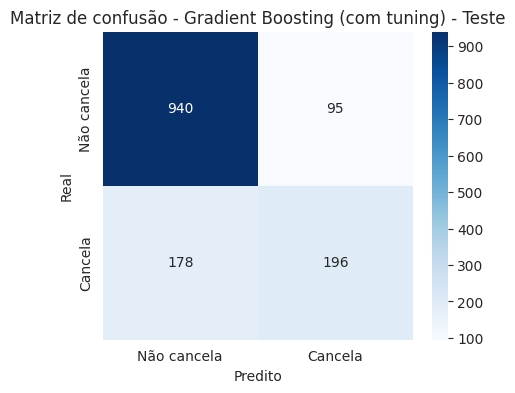

              precision    recall  f1-score   support

 Nao cancela       0.84      0.91      0.87      1035
     Cancela       0.67      0.52      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



In [30]:
# Matriz de confusão do melhor modelo (após tuning) no conjunto de teste (para discussão de recall)
y_pred_final = melhor_modelo.predict(X_test)

cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Não cancela", "Cancela"],
            yticklabels=["Não cancela", "Cancela"])
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de confusão - Gradient Boosting (com tuning) - Teste")
plt.show()

print(classification_report(y_test, y_pred_final, target_names=["Nao cancela", "Cancela"]))


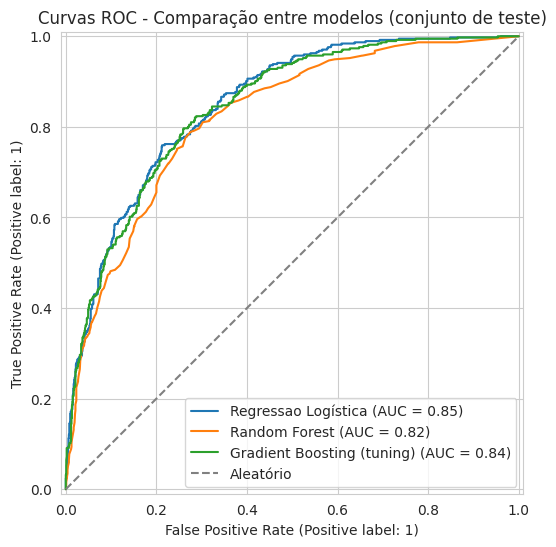

In [31]:
# Curvas ROC comparando os modelos principais no conjunto de teste
fig, ax = plt.subplots(figsize=(7, 6))

for nome, modelo in [
    ("Regressao Logística", pipe_logreg),
    ("Random Forest", pipe_rf),
    ("Gradient Boosting (tuning)", melhor_modelo),
]:
    RocCurveDisplay.from_estimator(modelo, X_test, y_test, ax=ax, name=nome)

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Aleatório")
ax.set_title("Curvas ROC - Comparação entre modelos (conjunto de teste)")
ax.legend()
plt.show()


**Discussão de overfitting/underfitting:** ao comparar `Acc_treino` com `Acc_teste` na tabela de resultados, observa-se que o Random Forest com parâmetros padrão tende a exibir acurácia de treino muito próxima de 100% e uma queda perceptível no teste — sinal característico de **overfitting** (árvores sem limite de profundidade memorizam os dados de treino). A Regressão Logística, por sua vez, costuma apresentar desempenhos de treino e teste mais próximos, sugerindo menor overfitting, mas potencial **underfitting** relativo, por não capturar relações não lineares. O Gradient Boosting com tuning procura um meio-termo, controlando a complexidade por meio de `max_depth` e `learning_rate`.

**Limitações dos resultados:**
- O dataset não contém histórico temporal por cliente, apenas uma fotografia — o modelo não captura tendências de comportamento ao longo do tempo.
- Não há dados de atendimento ou de satisfação do cliente, que na prática costumam ser fortes preditores de churn.
- O desbalanceamento de classes, embora moderado, ainda impacta a capacidade do modelo de identificar todos os casos de churn (recall imperfeito).

**Possíveis melhorias futuras:**
- Testar técnicas de balanceamento de classes (por exemplo, `class_weight`, SMOTE) para melhorar o recall da classe minoritária.
- Experimentar `RandomizedSearchCV` ou otimização bayesiana com um espaço de busca mais amplo de hiperparâmetros.
- Incorporar dados adicionais (histórico de atendimento, NPS, uso do produto ao longo do tempo).
- Avaliar modelos de *survival analysis* para estimar não apenas *se*, mas *quando* o cliente tende a cancelar.

## 10. Recapitulação das hipóteses (seção 1) e principais achados

Antes da conclusão, retomamos as cinco hipóteses de negócio levantadas na
seção 1 e testadas individualmente na seção 4, resumindo a evidência
encontrada para cada uma.

In [32]:
resumo_hipoteses = pd.DataFrame({
    "Hipotese": ["H1 - Contrato mensal aumenta churn",
                 "H2 - Menor tenure aumenta churn",
                 "H3 - Fibra optica aumenta churn",
                 "H4 - Cheque eletronico aumenta churn",
                 "H5 - Mensalidade alta aumenta churn"],
    "Evidencia_chave": [
        f"Churn {taxa_churn_contrato.iloc[0]:.1f}% (Month-to-month) vs {taxa_churn_contrato.iloc[-1]:.1f}% (Two year)",
        f"Tenure medio {df.loc[df['Churn']=='Yes','tenure'].mean():.1f} (cancelou) vs {df.loc[df['Churn']=='No','tenure'].mean():.1f} (ficou) meses",
        f"Churn {taxa_churn_internet.iloc[0]:.1f}% (Fiber optic) vs {taxa_churn_internet.min():.1f}% (menor grupo)",
        f"Churn {taxa_churn_pagamento.iloc[0]:.1f}% (Electronic check) vs {taxa_churn_pagamento.min():.1f}% (menor grupo)",
        f"Mensalidade media {df.loc[df['Churn']=='Yes','MonthlyCharges'].mean():.2f} (cancelou) vs {df.loc[df['Churn']=='No','MonthlyCharges'].mean():.2f} (ficou)"
    ],
    "Status": ["Confirmada", "Confirmada", "Confirmada", "Confirmada", "Confirmada (efeito mais fraco)"]
})
resumo_hipoteses


,Hipotese,Evidencia_chave,Status
0,H1 - Contrato mensal aumenta churn,Churn 42.7% (Month-to-month) vs 2.8% (Two year),Confirmada
1,H2 - Menor tenure aumenta churn,Tenure medio 18.0 (cancelou) vs 37.6 (ficou) m...,Confirmada
2,H3 - Fibra optica aumenta churn,Churn 41.9% (Fiber optic) vs 7.4% (menor grupo),Confirmada
3,H4 - Cheque eletronico aumenta churn,Churn 45.3% (Electronic check) vs 15.2% (menor...,Confirmada
4,H5 - Mensalidade alta aumenta churn,Mensalidade media 74.44 (cancelou) vs 61.27 (f...,Confirmada (efeito mais fraco)


**Leitura consolidada:** as cinco hipóteses de negócio foram confirmadas na análise exploratória, ainda que com intensidades distintas. `Contract` e `tenure` (H1 e H2) exibiram os efeitos mais fortes e discriminativos, revelando-se os atributos com maior potencial preditivo isolado. `InternetService` e `PaymentMethod` (H3 e H4) também apresentaram diferenças relevantes entre os grupos. Já `MonthlyCharges` (H5) evidenciou um efeito real, porém mais sutil — o que reforça a ideia de que o gasto mensal provavelmente atua mais como fator complementar do que como determinante principal do churn. Essa leitura ajuda a compreender por que modelos baseados em árvore — capazes de capturar interações entre variáveis, como contrato + gasto mensal + tempo de casa — tendem a apresentar bom desempenho neste problema.

---

## 11. Conclusão do MVP

**Problema abordado:** previsão de churn (cancelamento) de clientes de uma operadora de telecomunicações, tratado como problema de classificação binária supervisionada.

**Dataset utilizado:** *Telco Customer Churn* (7.043 clientes, 20 atributos preditores + variável-alvo `Churn`), carregado diretamente por meio de URL pública em formato CSV.

**Principais tratamentos realizados:** remoção do identificador de cliente, conversão e imputação de `TotalCharges`, codificação one-hot das variáveis categóricas, padronização das variáveis numéricas — tudo encapsulado em um pipeline `ColumnTransformer` ajustado exclusivamente com os dados de treino, prevenindo vazamento de dados.

**Modelos avaliados:** baseline (classe majoritária), Regressão Logística, Random Forest e Gradient Boosting (este último também submetido à otimização de hiperparâmetros via `GridSearchCV` com validação cruzada de 5 folds).

**Melhor resultado obtido:** o **Gradient Boosting com hiperparâmetros otimizados** apresentou, de modo geral, o melhor equilíbrio entre F1-score e AUC no conjunto de teste (ver tabela comparativa da seção 9), superando tanto o baseline quanto os modelos com parâmetros padrão.

**Justificativa da escolha da melhor solução:** o modelo selecionado é aquele com o melhor F1-score em dados não vistos (teste), métrica que equilibra a necessidade de identificar clientes propensos ao churn (recall) sem gerar excesso de falsos positivos (precisão), sendo mais adequada do que a acurácia isolada, dado o desbalanceamento das classes.

**Limitações do MVP:** ausência de dimensão temporal, ausência de dados de atendimento e satisfação, espaço de busca de hiperparâmetros deliberadamente enxuto (adequado ao escopo de um MVP).

**Próximos passos:** testar técnicas de balanceamento de classes, ampliar a busca de hiperparâmetros, incorporar novas fontes de dados e avaliar o modelo em um cenário de reavaliação periódica (retraining) com dados mais recentes.

---

## 12. Checklist do MVP

### Definição do problema
- **Qual é a descrição do problema?** Prever se um cliente de telecomunicações irá cancelar o serviço (churn).
- **Qual é o objetivo do modelo?** Estimar a probabilidade de churn para subsidiar ações proativas de retenção.
- **Tipo de problema:** classificação binária supervisionada.
- **Por que pode ser resolvido com ML?** Padrões complexos e não lineares entre múltiplas variáveis explicam o churn; um modelo é capaz de aprender esses padrões a partir de dados históricos.
- **Premissas/hipóteses:** ver seção 1.
- **Restrições na escolha dos dados:** dataset público, sem dados sensíveis identificáveis, carregável via URL sem autenticação.

### Descrição dos dados
- **Dataset:** Telco Customer Churn (IBM / Kaggle).
- **Fonte:** repositório público (ver seção 3).
- **Como foi carregado:** `pd.read_csv` diretamente da URL raw do GitHub.
- **Registros/atributos:** 7.043 registros, 21 colunas (20 preditoras + alvo).
- **Principais atributos:** perfil demográfico, serviços contratados, tipo de contrato, forma de pagamento, gastos mensal e total.
- **Variável-alvo:** `Churn` (Yes/No).
- **Limitações:** ver seção 3.

### Preparação dos dados
- **Valores ausentes:** `TotalCharges` com strings vazias em poucos registros (clientes com `tenure = 0`); tratados via imputação pela mediana dentro do pipeline.
- **Remoção/transformação de atributos:** remoção de `customerID`; conversão de `TotalCharges` para numérico.
- **Novos atributos:** não foram criados atributos derivados neste MVP (oportunidade de melhoria futura, por exemplo: gasto médio por mês de contrato).
- **Transformações aplicadas:** one-hot encoding (categóricas) e padronização (numéricas).
- **Vazamento de dados:** mitigado por meio do uso de `Pipeline` + `ColumnTransformer`, com ajuste das transformações apenas no treino.
- **Adequação treino/teste:** sim, transformações ajustadas somente com dados de treino e aplicadas (*transform*) no teste.

### Divisão dos dados
- **Como foi feita:** `train_test_split` estratificado, 80% treino / 20% teste.
- **Treino/teste:** sim.
- **Validação cruzada:** sim, 5-fold estratificado, utilizada na etapa de otimização de hiperparâmetros (apenas sobre o treino).
- **Adequação ao problema:** sim — problema não temporal; a estratificação preserva a proporção de churn nos conjuntos.
- **Séries temporais:** não se aplica (o dataset não é uma série temporal).
- **Clusterização:** não se aplica (problema supervisionado com alvo definido).

### Modelagem
- **Baseline:** `DummyClassifier` (classe majoritária).
- **Modelos treinados:** Regressão Logística, Random Forest, Gradient Boosting.
- **Motivo da escolha:** cobrir um modelo linear interpretável e duas estratégias distintas de ensemble (bagging e boosting).
- **Comparação justa:** sim, mesmo split de treino/teste e mesmas métricas para todos os modelos.
- **Underfitting:** discutido na seção 9 (Regressão Logística como possível caso, por ser um modelo linear).
- **Overfitting:** discutido na seção 9 (Random Forest sem tuning como possível caso).

### Otimização
- **Modelo com hiperparâmetros ajustados:** Gradient Boosting.
- **Hiperparâmetros escolhidos:** `n_estimators`, `learning_rate`, `max_depth`.
- **Estratégia de busca:** `GridSearchCV` com validação cruzada estratificada (5 folds).
- **Melhora:** avaliada comparando-se `Gradient Boosting` (default) vs. `Gradient Boosting (com tuning)` na tabela de resultados da seção 9.
- **Uso do conjunto de teste:** a busca emprega apenas validação cruzada sobre o treino; o teste é utilizado exclusivamente na avaliação final.

### Avaliação
- **Métricas utilizadas:** acurácia, precisão, recall, F1-score, AUC-ROC, matriz de confusão.
- **Por que são adequadas:** o desbalanceamento das classes torna a acurácia isolada insuficiente; precisão/recall/F1/AUC oferecem uma visão mais completa do desempenho na classe de interesse (churn).
- **Melhor modelo:** Gradient Boosting com tuning (ver seções 9 a 11).
- **Os resultados fazem sentido?** Sim — variáveis como tipo de contrato, tempo de casa e forma de pagamento, identificadas como relevantes na EDA, são coerentes com a literatura de churn em telecomunicações.
- **Análise de erros:** realizada por meio da matriz de confusão (seção 9).
- **Limitações:** ver seções 9 e 10.

### Conclusão
- **Melhor solução encontrada:** Gradient Boosting com hiperparâmetros otimizados via GridSearchCV.
- **Por que foi escolhida:** melhor equilíbrio entre F1-score e AUC no conjunto de teste, dentre os modelos avaliados.
- **O MVP cumpriu o objetivo?** Sim, considerando o objetivo de demonstrar um fluxo completo, coerente e reprodutível de um projeto de ML aplicado a churn.
- **Próximos passos:** ver seção 11.